# Notebook 01: Synthetic Ellipse Case Study

**Obstacle-Aware Clustering for Geographic Data**

This notebook demonstrates why standard k-Means fails in the presence of geographic obstacles and how a loop-aware arc-length parameter corrects the problem. We work through a fully controlled synthetic example using an elliptical obstacle before applying the method to real-world data in later notebooks.

---

## 1. Setup

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import (
    EllipseBoundary, ObstacleKMeans,
    loop_aware_distance, plot_clusters, plot_comparison
)

# Reproducibility
SEED = 23
np.random.seed(SEED)

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Defining the Obstacle

We define our obstacle as the level set of a 2D Gaussian function at threshold $c$:

$$A \cdot \exp\!\left(-\frac{(x-h)^2}{2\sigma_x^2} - \frac{(y-k)^2}{2\sigma_y^2}\right) = c$$

Setting $f(x,y) = c$ picks out a specific contour line of the Gaussian — the boundary of the obstacle. To find its shape, we take the log of both sides and rearrange:

$$\frac{(x-h)^2}{2\sigma_x^2} + \frac{(y-k)^2}{2\sigma_y^2} = -\ln(c/A)$$

Dividing through by $-\ln(c/A)$ puts this in the standard ellipse form $\frac{(x-h)^2}{a^2} + \frac{(y-k)^2}{b^2} = 1$, where the semi-axes are:

$$a = \sigma_x\sqrt{-2\ln(c/A)}, \qquad b = \sigma_y\sqrt{-2\ln(c/A)}$$

The shared factor $\sqrt{-2\ln(c/A)}$ (called `sqrt_term` in the code) is determined entirely by the ratio $c/A$. Different ratios produce different sized ellipses — a smaller ratio means a larger boundary — but the *shape* is controlled by $\sigma_x$ and $\sigma_y$.

Using the identity $\cos^2(t) + \sin^2(t) = 1$, we can write the ellipse parametrically:

$$x(t) = \sigma_x \sqrt{-2\ln(c/A)}\,\cos(t) + h, \qquad y(t) = \sigma_y \sqrt{-2\ln(c/A)}\,\sin(t) + k$$

for $t \in [0, 2\pi]$. This parametric form is essential — it gives us a single variable $t$ that tracks position along the boundary, which we need for computing arc lengths.


Total arc length of ellipse: 38.2575
Sqrt term (semi-axis scale): 3.0349


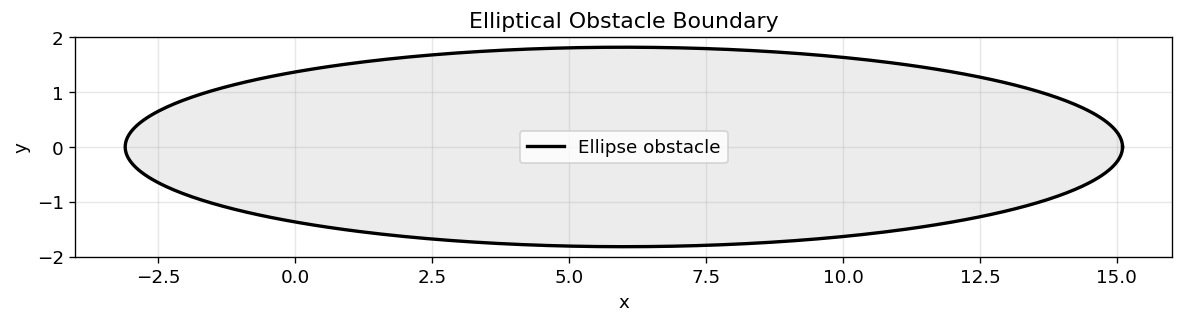

In [ ]:
# Define the ellipse boundary
boundary = EllipseBoundary(
    sigma_x=3.0, sigma_y=0.6, #wide ellipse; 5:1 ratio
    h=6.0, k=0.0, #center at (6,0)
    c=0.01, A=1.0 #c/A = about 3.03, producing semi-axes a=9.1, b=1.8
)

# Compute and display total arc length
L = boundary.total_arc_length()
print(f'Total arc length of ellipse: {L:.4f}')
print(f'Sqrt term (semi-axis scale): {boundary.sqrt_term:.4f}')

# Plot the ellipse
boundary_pts = boundary.sample_boundary(500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k-', linewidth=2, label='Ellipse obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.15, color='gray')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Elliptical Obstacle Boundary')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Generating Synthetic Data

We generate three clusters of points around the ellipse, each with distinct spatial positions and attribute values. For each cluster, we sample:

- **Geographic coordinates** $(x, y)$: uniform base + Gaussian noise, positioned around different parts of the ellipse
- **Housing price** $h$: drawn from cluster-specific Gaussian distributions (simulating an attribute like property value)
- **Favorability rating** $r$: drawn from cluster-specific Gaussians

The clusters are placed so that two of them sit on opposite sides of the ellipse but are relatively close in Euclidean distance. This is the scenario where standard k-Means will fail.

In [16]:
def generate_synthetic_data(n=10, seed=77):
    """Generate synthetic data around an elliptical obstacle.
    
    Three clusters simulate neighborhoods around a lake:
      - North shore: expensive homes, low ratings
      - South shore: affordable homes, high ratings  
      - West shore:  mid-range homes and ratings
    
    Clusters 0 and 1 share the same x-range but are separated by the
    obstacle, creating the scenario where standard k-Means fails.
    """
    np.random.seed(seed)
    
    # Cluster 0: North shore (above the ellipse, center to right)
    x0 = np.array([3, 5, 6, 7, 8, 9, 10, 11, 12, 13]) + np.random.normal(0, 0.3, n)
    y0 = np.array([2.5, 2.3, 2.2, 2.1, 2.0, 2.0, 2.1, 2.2, 2.3, 2.0]) + np.random.normal(0, 0.15, n)
    h0 = np.random.normal(500000, 50000, n)  # Expensive homes
    r0 = np.random.normal(0.3, 0.08, n)      # Low favorability
    
    # Cluster 1: South shore (below the ellipse, same x-range!)
    x1 = np.array([3, 5, 6, 7, 8, 9, 10, 11, 12, 13]) + np.random.normal(0, 0.3, n)
    y1 = np.array([-2.5, -2.3, -2.2, -2.1, -2.0, -2.0, -2.1, -2.2, -2.3, -2.0]) + np.random.normal(0, 0.15, n)
    h1 = np.random.normal(200000, 50000, n)  # Affordable homes
    r1 = np.random.normal(0.8, 0.08, n)      # High favorability
    
    # Cluster 2: West shore (wrapping around the left tip)
    x2 = np.array([-2, -2.5, -3, -2.5, -2, -1, 0, -1, -2, -3]) + np.random.normal(0, 0.3, n)
    y2 = np.array([1.5, 1.0, 0.0, -1.0, -1.5, -2.0, 0.0, 2.0, -0.5, 0.5]) + np.random.normal(0, 0.15, n)
    h2 = np.random.normal(350000, 50000, n)  # Mid-range homes
    r2 = np.random.normal(0.55, 0.08, n)     # Medium favorability
    
    raw_data = np.vstack([
        np.column_stack([x0, y0, h0, r0]),
        np.column_stack([x1, y1, h1, r1]),
        np.column_stack([x2, y2, h2, r2])
    ])
    true_labels = np.array([0]*n + [1]*n + [2]*n)
    
    return raw_data, true_labels


# Generate data
raw_data, true_labels = generate_synthetic_data()
print(f'Generated {len(raw_data)} data points across 3 clusters')
print(f'Columns: x, y, housing_price, rating')
print(f'Shape: {raw_data.shape}')

Generated 30 data points across 3 clusters
Columns: x, y, housing_price, rating
Shape: (30, 4)


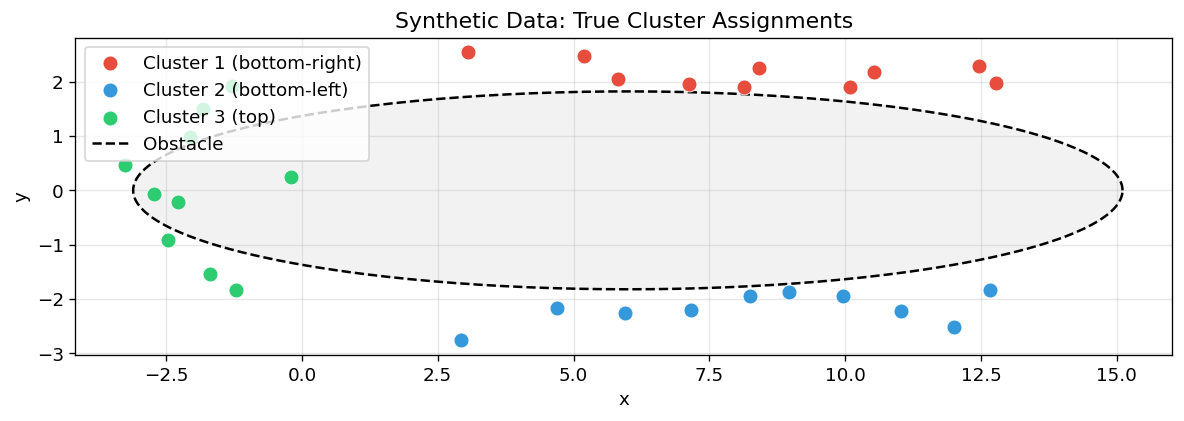

In [17]:
# Visualize raw data with true cluster labels and the ellipse
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = ['Cluster 1 (bottom-right)', 'Cluster 2 (bottom-left)', 'Cluster 3 (top)']

for i in range(3):
    mask = true_labels == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=colors[i],
              s=80, edgecolors='white', linewidth=0.5, label=labels[i], zorder=3)

# Ellipse
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Synthetic Data: True Cluster Assignments')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Failure of Standard k-Means

Standard k-Means uses Euclidean distance in $(x, y)$ to assign points to clusters. It has no concept of the obstacle — it treats the space as unobstructed. As a result, points on opposite sides of the ellipse may be grouped together simply because their straight-line distance is small.

Let's see this in action.

c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mpp24\AppData\Local\Temp\ipykernel_28400\399683179.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', 3)


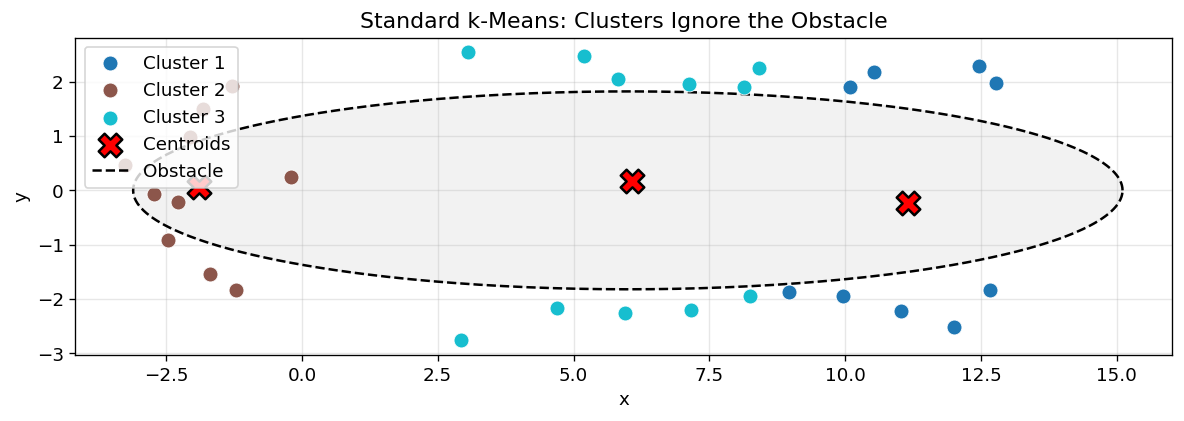

Notice: standard k-Means may group points from opposite sides of the ellipse
because it only considers straight-line distance, ignoring the barrier.


In [18]:
# Run standard k-Means on (x, y) only
xy_data = raw_data[:, :2]

kmeans_standard = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labels_standard = kmeans_standard.fit_predict(xy_data)

# Plot standard k-Means result
fig, ax = plt.subplots(figsize=(10, 6))
cmap = cm.get_cmap('tab10', 3)

for i in range(3):
    mask = labels_standard == i
    ax.scatter(xy_data[mask, 0], xy_data[mask, 1], c=[cmap(i)],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)

# Centroids
ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4, label='Centroids')

# Ellipse
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-Means: Clusters Ignore the Obstacle')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Notice: standard k-Means may group points from opposite sides of the ellipse')
print('because it only considers straight-line distance, ignoring the barrier.')

## 5. The Arc-Length Parameter $s$

To encode obstacle awareness, we introduce a normalized arc-length parameter $s \in [0, 1]$ for each data point:

1. **Project** the point onto the nearest location on the ellipse boundary
2. **Compute** the arc length from a reference point ($t=0$) to the projection
3. **Normalize** by the total perimeter: $s = \text{arc length} \,/\, L$

The key insight is the **loop-aware distance**:

$$d_s(s_1, s_2) = \min\big(|s_1 - s_2|,\; 1 - |s_1 - s_2|\big)$$

This accounts for the closed-loop topology. Points with $s = 0.05$ and $s = 0.95$ are actually close (distance = 0.10), not far apart (0.90).

In [19]:
# Project each data point onto the ellipse and compute s
t_values = []
s_values = []

for x_p, y_p in raw_data[:, :2]:
    t_closest, s_closest = boundary.project_point(x_p, y_p)
    t_values.append(t_closest)
    s_values.append(s_closest)

t_values = np.array(t_values)
s_values = np.array(s_values)

print('Arc-length values (s) for each point:')
for i, (x, y, s) in enumerate(zip(raw_data[:, 0], raw_data[:, 1], s_values)):
    print(f'  Point {i:2d}: ({x:6.2f}, {y:6.2f})  →  s = {s:.4f}')

Arc-length values (s) for each point:
  Point  0: (  3.07,   2.55)  →  s = 0.3253
  Point  1: (  5.20,   2.47)  →  s = 0.2707
  Point  2: (  5.83,   2.04)  →  s = 0.2545
  Point  3: (  7.12,   1.95)  →  s = 0.2208
  Point  4: (  8.14,   1.90)  →  s = 0.1942
  Point  5: (  8.41,   2.25)  →  s = 0.1877
  Point  6: ( 10.08,   1.91)  →  s = 0.1438
  Point  7: ( 10.53,   2.17)  →  s = 0.1332
  Point  8: ( 12.47,   2.29)  →  s = 0.0850
  Point  9: ( 12.78,   1.98)  →  s = 0.0758
  Point 10: (  2.93,  -2.76)  →  s = 0.6717
  Point 11: (  4.69,  -2.17)  →  s = 0.7160
  Point 12: (  5.95,  -2.27)  →  s = 0.7487
  Point 13: (  7.17,  -2.20)  →  s = 0.7802
  Point 14: (  8.24,  -1.94)  →  s = 0.8084
  Point 15: (  8.96,  -1.88)  →  s = 0.8272
  Point 16: (  9.95,  -1.94)  →  s = 0.8528
  Point 17: ( 11.02,  -2.22)  →  s = 0.8792
  Point 18: ( 12.01,  -2.51)  →  s = 0.9027
  Point 19: ( 12.66,  -1.83)  →  s = 0.9220
  Point 20: ( -1.82,   1.50)  →  s = 0.4520
  Point 21: ( -2.06,   0.98)  →  s = 0

C:\Users\mpp24\Documents\obstacle-aware-clustering\src\obstacle_clustering\boundary.py:222: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  t_closest = t_closest % (2 * np.pi)


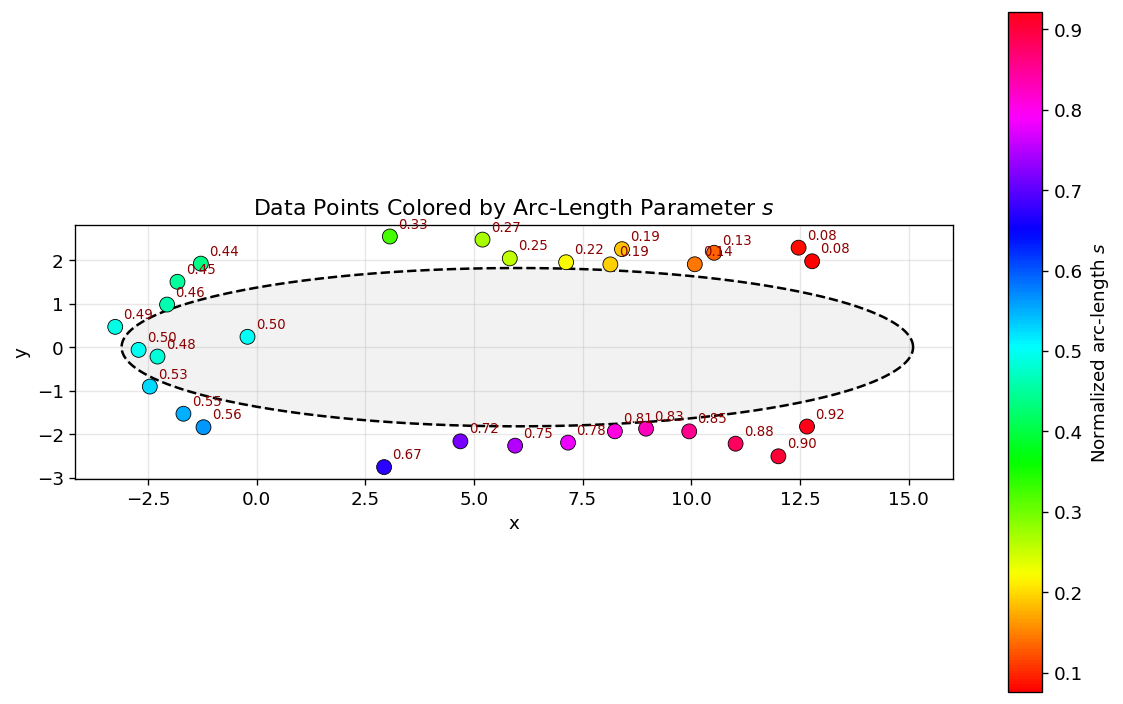

In [20]:
# Visualize points with their s values labeled
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(raw_data[:, 0], raw_data[:, 1], c=s_values, cmap='hsv',
                     s=80, edgecolors='black', linewidth=0.5, zorder=3)
plt.colorbar(scatter, ax=ax, label='Normalized arc-length $s$')

# Label each point with its s value
for i, (x, y, s) in enumerate(zip(raw_data[:, 0], raw_data[:, 1], s_values)):
    ax.annotate(f'{s:.2f}', (x, y), textcoords='offset points',
               xytext=(5, 5), fontsize=8, color='darkred')

# Ellipse
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data Points Colored by Arc-Length Parameter $s$')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Demonstrate loop-aware distance
print('Loop-aware distance examples:')
print(f'  d(0.05, 0.95) = {loop_aware_distance(0.05, 0.95):.2f}  (close — wraps around)')
print(f'  d(0.05, 0.50) = {loop_aware_distance(0.05, 0.50):.2f}  (far — opposite sides)')
print(f'  d(0.30, 0.70) = {loop_aware_distance(0.30, 0.70):.2f}  (moderately far)')
print(f'  d(0.10, 0.20) = {loop_aware_distance(0.10, 0.20):.2f}  (close — same region)')

Loop-aware distance examples:
  d(0.05, 0.95) = 0.10  (close — wraps around)
  d(0.05, 0.50) = 0.45  (far — opposite sides)
  d(0.30, 0.70) = 0.40  (moderately far)
  d(0.10, 0.20) = 0.10  (close — same region)


## 6. Feature Engineering

We now construct the full feature vector for each data point. All features are normalized to $[0, 1]$ so that no single dimension dominates the distance calculation:

$$\mathbf{x}_i = (x_i^{\text{scaled}},\; y_i^{\text{scaled}},\; s_i,\; h_i^{\text{scaled}},\; r_i^{\text{scaled}})$$

Note that $s$ is already in $[0, 1]$ by construction.

In [22]:
# Normalize features
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(raw_data[:, :2])

scaler_h = MinMaxScaler()
h_scaled = scaler_h.fit_transform(raw_data[:, 2:3])

# r values are already roughly in [0, 1], but normalize for consistency
scaler_r = MinMaxScaler()
r_scaled = scaler_r.fit_transform(raw_data[:, 3:4])

# Combine into feature matrix: [x, y, s, h, r]
X = np.column_stack([xy_scaled, s_values, h_scaled.ravel(), r_scaled.ravel()])

print(f'Feature matrix shape: {X.shape}')
print(f'Features: x_scaled, y_scaled, s, h_scaled, r_scaled')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (30, 5)
Features: x_scaled, y_scaled, s, h_scaled, r_scaled

First 5 rows:
[[0.3941 1.     0.3253 0.7864 0.0373]
 [0.527  0.9866 0.2707 0.7192 0.    ]
 [0.5661 0.9051 0.2545 0.6839 0.2116]
 [0.647  0.8883 0.2208 0.754  0.1637]
 [0.7104 0.879  0.1942 0.5546 0.0702]]


## 7. Obstacle-Aware k-Means

Our modified k-Means uses a weighted composite distance:

$$d^2(\mathbf{x}_i, \mathbf{c}_j) = \alpha^2 \|(x_i, y_i) - (c_{jx}, c_{jy})\|^2 + \beta^2\, d_s(s_i, s_{c_j})^2 + \gamma^2\big((h_i - h_{c_j})^2 + (r_i - r_{c_j})^2\big)$$

The three weight parameters control the balance between:
- $\alpha$: geographic proximity (Euclidean in $x, y$)
- $\beta$: position along the obstacle (loop-aware in $s$)
- $\gamma$: attribute similarity (housing price, rating)

The centroid update for $s$ uses **boundary-aware projection**: instead of naively averaging $s$ values (which would fail on a circle), we map cluster members back to boundary coordinates, average those, and re-project onto the boundary.

In [23]:
# Run obstacle-aware k-Means
model = ObstacleKMeans(
    k=3,
    boundary=boundary,
    alpha=1.0,
    beta=1.0,
    gamma=1.0,
    random_state=35,
    n_attr=2  # h and r are the attribute features
)
model.fit(X, t_data=t_values)

labels_obstacle = model.labels_

print(f'Converged in {model.n_iter_} iterations')
print(f'Within-cluster distortion (rho_bar): {model.rho_bar_:.6f}')
print(f'Cluster assignments: {labels_obstacle}')

Converged in 2 iterations
Within-cluster distortion (rho_bar): 0.047002
Cluster assignments: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]


## 8. Comparison: Standard vs. Obstacle-Aware

Now we can directly compare the two approaches side by side. The key question: does the obstacle-aware version produce clusters that respect the boundary geometry?

C:\Users\mpp24\AppData\Local\Temp\ipykernel_28400\1617016859.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', 3)


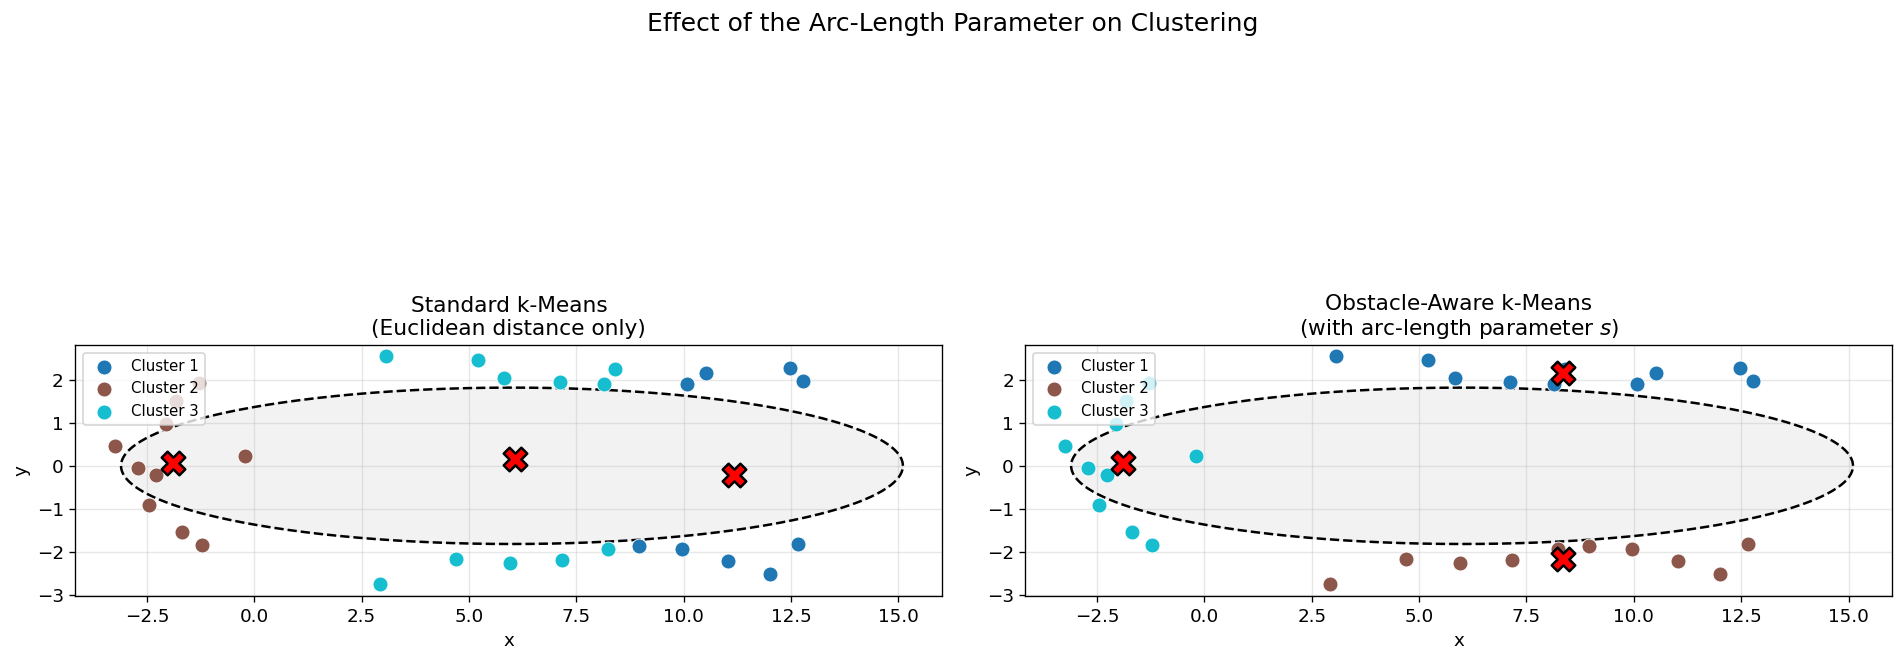

In [24]:
# Side-by-side comparison using original (unscaled) coordinates
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Standard k-Means ---
ax = axes[0]
cmap = cm.get_cmap('tab10', 3)
for i in range(3):
    mask = labels_standard == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=[cmap(i)],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)
ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4)
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='gray')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-Means\n(Euclidean distance only)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Obstacle-Aware k-Means ---
ax = axes[1]
for i in range(3):
    mask = labels_obstacle == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=[cmap(i)],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)

# Compute centroids in original coordinates for plotting
for i in range(3):
    mask = labels_obstacle == i
    cx = np.mean(raw_data[mask, 0])
    cy = np.mean(raw_data[mask, 1])
    ax.scatter(cx, cy, c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4)

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='gray')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Obstacle-Aware k-Means\n(with arc-length parameter $s$)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Effect of the Arc-Length Parameter on Clustering', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 9. Cluster Summaries

Let's examine the composition of each obstacle-aware cluster to verify that the algorithm produces groups that differ meaningfully in both spatial position and attributes.

In [12]:
# Summarize each cluster
feature_names = ['x_scaled', 'y_scaled', 's', 'h_scaled', 'r_scaled']
summaries = model.get_cluster_summary(X, feature_names=feature_names)

for s in summaries:
    print(f"\nCluster {s['cluster'] + 1} ({s['size']} points):")
    print(f"  Centroid: {[f'{v:.3f}' for v in s['centroid']]}")
    for fname, stats in s['features'].items():
        print(f"  {fname:12s}: mean={stats['mean']:.3f}, std={stats['std']:.3f}")


Cluster 1 (7 points):
  Centroid: ['0.133', '0.154', '0.624', '0.164', '0.883']
  x_scaled    : mean=0.133, std=0.104
  y_scaled    : mean=0.154, std=0.037
  s           : mean=0.624, std=0.033
  h_scaled    : mean=0.164, std=0.100
  r_scaled    : mean=0.883, std=0.054

Cluster 2 (7 points):
  Centroid: ['0.743', '0.067', '0.823', '0.879', '0.248']
  x_scaled    : mean=0.743, std=0.181
  y_scaled    : mean=0.067, std=0.068
  s           : mean=0.823, std=0.058
  h_scaled    : mean=0.879, std=0.098
  r_scaled    : mean=0.248, std=0.133

Cluster 3 (7 points):
  Centroid: ['0.733', '0.914', '0.181', '0.470', '0.574']
  x_scaled    : mean=0.733, std=0.109
  y_scaled    : mean=0.914, std=0.053
  s           : mean=0.181, std=0.034
  h_scaled    : mean=0.470, std=0.144
  r_scaled    : mean=0.574, std=0.089


## 10. Discussion

This synthetic case study demonstrates the core ideas:

1. **Standard k-Means fails** when obstacles separate data points that are close in Euclidean distance but far apart by any realistic path.

2. **The arc-length parameter** $s$ encodes position along the obstacle boundary. Its loop-aware distance respects the closed-curve topology.

3. **The modified k-Means** combines Euclidean geography, loop-aware arc-length, and attribute features in a single weighted distance. Centroid updates for $s$ use boundary-aware projection rather than naive averaging.

4. **The approach is general**: it does not depend on the obstacle being an ellipse. Any smooth closed curve that admits a parameterization will work — including cubic splines fitted to real-world boundaries.

### Next Steps

In **Notebook 02**, we extract the Lake Tahoe boundary using ArcGIS and cubic splines. In **Notebook 03**, we apply the same algorithm to wildfire ignition data, where the lake is the obstacle and fire behavior attributes replace housing prices.